# Задача A. Reinforcement Learning — ATARI (Double DQN)

## Игра: Carnival

Реализация **Double Deep Q-Network (DDQN)** для обучения агента играть в **Carnival** на основе RGB-изображений экрана.

**Среда:** `CarnivalNoFrameskip-v4` (дискретное пространство действий, 6 действий)  
**Архитектура:** Свёрточная нейронная сеть (Nature DQN)  
**Функция потерь:** Double Q-Learning loss  

### Описание игры
Carnival — это «тир». По экрану горизонтально движутся мишени (кролики, утки, совы и др.),
и вы должны стрелять по ним из пушки, которая перемещается влево-вправо.
Запас патронов ограничен — куры могут украсть ваши пули, если вы не собьёте их вовремя.
Награда начисляется **за каждое попадание**, что делает эту игру идеальной для DQN —
обратная связь частая, агент быстро понимает какие действия приводят к наградам.

### 6 действий агента:
NOOP, FIRE, RIGHT, LEFT, RIGHTFIRE, LEFTFIRE

## 0. Установка зависимостей (выполнить один раз)

In [1]:
!pip install -q "gymnasium[atari]" ale-py autorom opencv-python-headless
!AutoROM --accept-license

AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.12/dist-packages/AutoROM/roms

Existing ROMs will be overwritten.
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/adventure.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/air_raid.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/alien.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/amidar.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/assault.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/asterix.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/asteroids.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/atlantis.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/atlantis2.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/backgammon.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/bank_heist.bin
Inst

## 1. Импорты и настройка GPU

In [2]:
import numpy as np
import gymnasium as gym
import ale_py
import tensorflow as tf
import collections
import time
import matplotlib.pyplot as plt
from IPython import display as ipythondisplay
import cv2

# Регистрация Atari-сред
gym.register_envs(ale_py)

# Настройка GPU
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU найдены: {len(gpus)}")
    except RuntimeError as e:
        print(e)
else:
    print("GPU не найден, используется CPU.")

print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {tf.keras.__version__}")

GPU найдены: 1
TensorFlow: 2.19.0
Keras: 3.13.2


## 2. Предобработка Atari (AtariPreprocessing)

Обёртка над средой, которая выполняет стандартную предобработку:
- **Frame skip (4 кадра)** — действие повторяется 4 раза, ускоряя обучение
- **Grayscale** — переводим цветное изображение в оттенки серого
- **Resize до 84×84** — уменьшаем размер для экономии памяти и вычислений
- **Стек 4 кадров** — 4 последовательных кадра дают информацию о движении мишеней
- **Clip reward** — награды обрезаются до {-1, 0, +1} для стабильности
- **Random no-ops** — случайное число пустых действий в начале для разнообразия

In [3]:
class AtariPreprocessing(gym.Wrapper):
    """Стандартная предобработка Atari."""

    def __init__(self, env, noop_max=30, frame_skip=4, screen_size=84,
                 grayscale=True, stack_frames=4,
                 clip_reward=True, seed=None):
        super().__init__(env)
        self.noop_max = noop_max
        self.frame_skip = frame_skip
        self.screen_size = screen_size
        self.grayscale = grayscale
        self.stack_frames = stack_frames
        self.clip_reward = clip_reward
        self.rng = np.random.default_rng(seed)

        self.frames = collections.deque(maxlen=stack_frames)

        # Определяем observation_space для стекированных кадров
        shape = (screen_size, screen_size)
        if grayscale:
            self.observation_space = gym.spaces.Box(
                low=0, high=255, shape=(*shape, stack_frames), dtype=np.uint8
            )
        else:
            self.observation_space = gym.spaces.Box(
                low=0, high=255, shape=(*shape, 3 * stack_frames), dtype=np.uint8
            )

    def _preprocess_frame(self, frame):
        """Конвертация в grayscale и resize до screen_size × screen_size."""
        if self.grayscale:
            gray = np.mean(frame, axis=-1).astype(np.uint8)
            resized = cv2.resize(gray, (self.screen_size, self.screen_size),
                                 interpolation=cv2.INTER_AREA)
            return resized  # (84, 84)
        else:
            resized = cv2.resize(frame, (self.screen_size, self.screen_size),
                                 interpolation=cv2.INTER_AREA)
            return resized  # (84, 84, 3)

    def _get_stacked(self):
        """Склеиваем стек кадров в один массив."""
        return np.concatenate(list(self.frames), axis=-1)

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        # Случайное число пустых действий в начале
        noops = self.rng.integers(1, self.noop_max + 1)
        for _ in range(noops):
            obs, _, terminated, truncated, info = self.env.step(0)
            if terminated or truncated:
                obs, info = self.env.reset(**kwargs)

        frame = self._preprocess_frame(obs)
        if self.grayscale:
            frame = frame[..., np.newaxis]  # (84,84) -> (84,84,1)
        for _ in range(self.stack_frames):
            self.frames.append(frame)
        return self._get_stacked(), info

    def step(self, action):
        total_reward = 0.0
        terminated = False
        truncated = False
        info = {}
        # Повторяем действие frame_skip раз
        for _ in range(self.frame_skip):
            obs, reward, terminated, truncated, info = self.env.step(action)
            total_reward += reward
            if terminated or truncated:
                break

        frame = self._preprocess_frame(obs)
        if self.grayscale:
            frame = frame[..., np.newaxis]
        self.frames.append(frame)

        if self.clip_reward:
            total_reward = np.sign(total_reward)

        done = terminated
        return self._get_stacked(), total_reward, done, truncated, info

print("AtariPreprocessing определён.")

AtariPreprocessing определён.


## 3. Создание среды

Используем **CarnivalNoFrameskip-v4** — без встроенного frame skip (мы делаем свой в обёртке).

Среда имеет:
- **6 дискретных действий:** NOOP, FIRE, RIGHT, LEFT, RIGHTFIRE, LEFTFIRE
- **Наблюдение:** RGB-изображение экрана 210×160, после предобработки → 84×84×4
- **Награды:** очки за каждое попадание по мишени (частые награды — хорошо для обучения!)

Форма наблюдения: (84, 84, 4)
Количество действий: 6


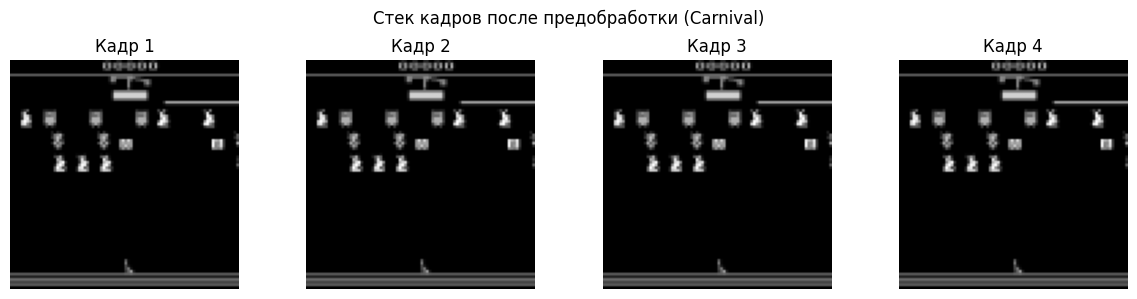


Мин. пиксель: 0, Макс. пиксель: 192, Тип: uint8


In [4]:
def make_env(env_name="CarnivalNoFrameskip-v4", seed=42):
    """Создаёт среду Carnival с предобработкой."""
    env = gym.make(env_name, render_mode="rgb_array")
    env = AtariPreprocessing(env, seed=seed)
    return env

env = make_env()
n_actions = env.action_space.n
obs_shape = env.observation_space.shape
print(f"Форма наблюдения: {obs_shape}")
print(f"Количество действий: {n_actions}")

# Визуализация начального наблюдения
obs, _ = env.reset()
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):
    axes[i].imshow(obs[:, :, i], cmap='gray')
    axes[i].set_title(f'Кадр {i+1}')
    axes[i].axis('off')
plt.suptitle('Стек кадров после предобработки (Carnival)')
plt.tight_layout()
plt.show()

print(f"\nМин. пиксель: {obs.min()}, Макс. пиксель: {obs.max()}, Тип: {obs.dtype}")

## 4. Буфер воспроизведения (Replay Buffer)

Кольцевой буфер, хранящий переходы `(s, a, r, s', done)`.

Случайная выборка из буфера разрывает корреляцию между последовательными кадрами,
что критически важно для стабильного обучения DQN.

In [5]:
class ReplayBuffer:

    def __init__(self, max_size: int, observation_space: gym.spaces.Space,
                 action_space: gym.spaces.Space, seed: int | None = None):
        """Stores the replay history with a maximum of `max_size` entries,
        removing old entries as needed.

        Parameters:
            max_size: maximal number of entries to keep
            observation_space: specification of the observation space
            action_space: specification of the action space
            seed: seed to initialize the internal random number generator for reproducibility
        """
        self.max_size = max_size
        self.rng = np.random.default_rng(seed)
        self.pos = 0
        self.size = 0

        obs_shape = observation_space.shape
        self.observations = np.zeros((max_size, *obs_shape), dtype=np.uint8)
        self.next_observations = np.zeros((max_size, *obs_shape), dtype=np.uint8)
        self.actions = np.zeros(max_size, dtype=np.int32)
        self.rewards = np.zeros(max_size, dtype=np.float32)
        self.dones = np.zeros(max_size, dtype=np.float32)

    def add(self, current_observation: np.ndarray, action: int, reward: float,
            next_observation: np.ndarray, done: bool) -> None:
        """Add a new entry to the buffer.

        Parameters:
            current_observation: environment state observed at the current step
            action: action taken by the model
            reward: reward received after taking the action
            next_observation: environment state observed after taking the action
            done: whether the episode has ended or not
        """
        self.observations[self.pos] = current_observation
        self.actions[self.pos] = action
        self.rewards[self.pos] = reward
        self.next_observations[self.pos] = next_observation
        self.dones[self.pos] = float(done)
        self.pos = (self.pos + 1) % self.max_size
        self.size = min(self.size + 1, self.max_size)

    def sample(self, n_samples: int, replace: bool = True) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        """Randomly samples `n_samples` from the buffer.

        Parameters:
            n_samples: number of samples to select
            replace: sample with or without replacement

        Returns:
            current observations, actions, rewards, next observations, done
        """
        indices = self.rng.choice(self.size, size=n_samples, replace=replace)
        return (
            self.observations[indices],
            self.actions[indices],
            self.rewards[indices],
            self.next_observations[indices],
            self.dones[indices],
        )

    def clear(self) -> None:
        """Clears the buffer."""
        self.pos = 0
        self.size = 0

    def __getitem__(self, index: int) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        """Gets a sample at `index`.

        Parameters:
            index: index of the sample to get

        Returns:
            current observation, action, reward, next observation, done
        """
        assert 0 <= index < self.size
        return (
            self.observations[index],
            self.actions[index],
            self.rewards[index],
            self.next_observations[index],
            self.dones[index],
        )

    def __len__(self) -> int:
        """Returns the number of entries in the buffer."""
        return self.size


# Тест
buffer = ReplayBuffer(max_size=100_000, observation_space=env.observation_space,
                       action_space=env.action_space, seed=42)
print(f"Буфер создан. Максимальный размер: {buffer.max_size}")
print(f"Примерный расход RAM: {2 * buffer.max_size * np.prod(obs_shape) / 1e9:.1f} ГБ")

Буфер создан. Максимальный размер: 100000
Примерный расход RAM: 5.6 ГБ


## 5. Свёрточная модель (Nature DQN)

Архитектура из статьи DeepMind *"Human-level control through deep reinforcement learning"* (Mnih et al., 2015):

- **Rescaling:** пиксели [0, 255] → [0.0, 1.0]
- **Conv2D(32, 8×8, stride 4, ReLU)** — крупные признаки (структура экрана, ряды мишеней)
- **Conv2D(64, 4×4, stride 2, ReLU)** — средние признаки (отдельные мишени, пушка)
- **Conv2D(64, 3×3, stride 1, ReLU)** — мелкие детали (положение пуль, движение)
- **Flatten → Dense(512, ReLU)** — объединение признаков
- **Dense(6)** — Q-значение для каждого из 6 действий

In [8]:
def build_dqn(input_shape, n_actions, name="dqn"):

    n_actions = int(n_actions)

    inputs = tf.keras.Input(shape=input_shape, dtype=tf.uint8)

    # Нормализация пикселей [0, 255] -> [0, 1] через Keras-слой
    x = tf.keras.layers.Rescaling(scale=1.0 / 255.0)(inputs)

    x = tf.keras.layers.Conv2D(32, 8, strides=4, activation='relu',
                                kernel_initializer='he_normal')(x)
    x = tf.keras.layers.Conv2D(64, 4, strides=2, activation='relu',
                                kernel_initializer='he_normal')(x)
    x = tf.keras.layers.Conv2D(64, 3, strides=1, activation='relu',
                                kernel_initializer='he_normal')(x)
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(512, activation='relu',
                               kernel_initializer='he_normal')(x)
    q_values = tf.keras.layers.Dense(n_actions, activation=None,
                                      kernel_initializer='he_normal')(x)

    model = tf.keras.Model(inputs=inputs, outputs=q_values, name=name)
    return model


model = build_dqn(obs_shape, n_actions, name="online")
target_model = build_dqn(obs_shape, n_actions, name="target")
target_model.set_weights(model.get_weights())

model.summary()

# Тест: прогоняем наблюдение через модель
test_out = model(np.expand_dims(obs, axis=0), training=False)
print(f"\nФорма выхода: {test_out.shape}")
print(f"Q-значения для 6 действий: {test_out.numpy()[0]}")

Model: "online"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 84, 84, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 84, 84, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 20, 20, 32)     │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 9, 9, 64)       │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     1,606,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,687,206 (6.44 MB)

 Trainable params: 1,687,206 (6.44 MB)

 Non-trainable params: 0 (0.00 B)


Форма выхода: (1, 6)
Q-значения для 6 действий: [-0.07273369 -0.31215137  0.11299375  0.03031615 -0.01619902 -0.13238952]


## 6. Epsilon-Greedy Sampler

Стратегия выбора действий:
- С вероятностью **ε** — случайное действие (исследование)
- С вероятностью **1−ε** — действие с максимальным Q-значением (эксплуатация)

In [9]:
class Sampler:

    def __init__(self, epsilon: float, seed: int | None = None):
        """Selects a random action with probability `epsilon` otherwise selects
        the most probable action given by the model.

        Parameters:
            epsilon: the probability to select a random action
            seed: seed to initialize the internal random number generator for reproducibility
        """
        self.epsilon = epsilon
        self.rng = np.random.default_rng(seed)

    def __call__(self, q_values: np.ndarray) -> int:
        """Select an action given the Q-values.

        Parameters:
            q_values: Q-value estimates for each action (1D array)

        Returns:
            index of the selected action
        """
        if self.rng.random() < self.epsilon:
            return int(self.rng.integers(0, len(q_values)))
        return int(np.argmax(q_values))


# Тест
sampler = Sampler(epsilon=1.0, seed=42)
test_q = np.random.randn(6)
actions_chosen = [sampler(test_q) for _ in range(600)]
print("Полностью случайный (eps=1.0):")
print({a: actions_chosen.count(a) for a in range(6)})

sampler_greedy = Sampler(epsilon=0.0, seed=42)
print(f"Жадный (eps=0.0) всегда выбирает: {sampler_greedy(test_q)}")

Полностью случайный (eps=1.0):
{0: 106, 1: 102, 2: 93, 3: 92, 4: 100, 5: 107}
Жадный (eps=0.0) всегда выбирает: 1


## 7. Функция игры — взаимодействие со средой

In [10]:
def play_game(model: tf.keras.Model, buffer: ReplayBuffer | None,
              env: gym.Env, max_steps: int, sampler: Sampler,
              observation: np.ndarray | None = None):
    """Play game and record transitions to replay buffer.

    Parameters:
        model: the model to get actions with
        buffer: replay buffer to store the entries to
        env: environment to play
        max_steps: maximal number of steps to perform
        sampler: sampler to use to sample actions
        observation: the observation to resume from

    Returns:
        the last observation, total_reward, steps_played
    """
    if observation is None:
        observation, _ = env.reset()

    total_reward = 0.0
    steps = 0

    for _ in range(max_steps):
        obs_tensor = np.expand_dims(observation, axis=0)
        q_values = model(obs_tensor, training=False)
        if hasattr(q_values, 'numpy'):
            q_values = q_values.numpy()[0]
        else:
            q_values = np.array(q_values)[0]

        action = sampler(q_values)

        next_observation, reward, done, truncated, info = env.step(action)
        total_reward += reward
        steps += 1

        if buffer is not None:
            buffer.add(observation, action, reward, next_observation,
                       done or truncated)

        if done or truncated:
            observation, _ = env.reset()
        else:
            observation = next_observation

    return observation, total_reward, steps

print("Функция play_game определена.")

Функция play_game определена.


## 8. Double Q-Learning Loss

### Стандартный DQN:
$$y = r + \gamma \max_{a'} Q_{\theta^-}(s', a')$$

Проблема: $\max$ систематически **завышает** Q-значения.

### Double DQN (наша реализация):
$$y = r + \gamma \, Q_{\theta^-}\!\bigl(s',\; \arg\max_{a'} Q_\theta(s', a')\bigr)$$

Разделяем:
1. **Online-сеть** ($Q_\theta$) **выбирает** лучшее действие
2. **Target-сеть** ($Q_{\theta^-}$) **оценивает** это действие

Используем **Huber loss** (устойчив к выбросам в TD-ошибке).

In [11]:
@tf.function
def qq_loss(
    current_observation: tf.Tensor,
    action: tf.Tensor,
    reward: tf.Tensor,
    next_observation: tf.Tensor,
    done: tf.Tensor,
    model: tf.keras.Model,
    target_model: tf.keras.Model,
    gamma: float
) -> tf.Tensor:
    """Computes double q learning loss.

    Parameters:
        current_observation: observations at the current time step (B, 84, 84, 4)
        action: actions taken at the current time step (B,)
        reward: rewards at the current time step (B,)
        next_observation: observations at the next time step (B, 84, 84, 4)
        done: whether the episode has ended or not (B,)
        model: training model (online)
        target_model: target model
        gamma: discount factor

    Returns:
        Computed loss (scalar)
    """
    # Q-значения текущих состояний из online-сети
    q_values = model(current_observation, training=True)  # (B, 6)
    n_actions = tf.shape(q_values)[-1]

    # Извлекаем Q-значения для совершённых действий
    action_indices = tf.cast(action, tf.int32)
    action_mask = tf.one_hot(action_indices, n_actions, dtype=tf.float32)
    q_selected = tf.reduce_sum(q_values * action_mask, axis=-1)  # (B,)

    # --- Double DQN таргет ---
    # Шаг 1: Online-сеть ВЫБИРАЕТ лучшее действие
    next_q_online = model(next_observation, training=False)   # (B, 6)
    best_next_actions = tf.cast(tf.argmax(next_q_online, axis=-1), tf.int32)

    # Шаг 2: Target-сеть ОЦЕНИВАЕТ это действие
    next_q_target = target_model(next_observation, training=False)  # (B, 6)
    best_action_mask = tf.one_hot(best_next_actions, n_actions, dtype=tf.float32)
    next_q_selected = tf.reduce_sum(next_q_target * best_action_mask, axis=-1)

    # TD-таргет
    td_target = reward + gamma * next_q_selected * (1.0 - done)
    td_target = tf.stop_gradient(td_target)

    # Huber loss
    loss = tf.keras.losses.huber(td_target, q_selected)
    return tf.reduce_mean(loss)


# Тест
dummy_obs = np.random.randint(0, 255, size=(4, *obs_shape), dtype=np.uint8)
dummy_act = np.array([0, 1, 2, 3], dtype=np.int32)
dummy_rew = np.array([1.0, 0.0, -1.0, 1.0], dtype=np.float32)
dummy_next = np.random.randint(0, 255, size=(4, *obs_shape), dtype=np.uint8)
dummy_done = np.array([0.0, 0.0, 1.0, 0.0], dtype=np.float32)

test_loss = qq_loss(
    tf.constant(dummy_obs), tf.constant(dummy_act),
    tf.constant(dummy_rew), tf.constant(dummy_next),
    tf.constant(dummy_done), model, target_model, gamma=0.99
)
print(f"Тестовый лосс: {test_loss.numpy():.4f} ✓")

Тестовый лосс: 1.4359 ✓


## 9. Обучение

### Гиперпараметры

Carnival — игра с **частыми наградами** (очки за каждое попадание) и **6 действиями**.
Это значительно проще, чем Ice Hockey, и DQN учится быстро.

In [18]:
# ── Гиперпараметры ──
BUFFER_SIZE      = 100_000
BATCH_SIZE       = 2048
LEARNING_RATE    = 1e-4
GAMMA            = 0.99
EPS_START        = 1.0
EPS_END          = 0.1
EPS_DECAY_STEPS  = 300_000
TARGET_UPDATE    = 1_000
LEARNING_STARTS  = 10_000
TOTAL_STEPS      = 3_000_000
EVAL_EVERY       = 100_000
TRAIN_FREQ       = 4


# Пересоздаём все компоненты
env = make_env(seed=42)
model = build_dqn(obs_shape, n_actions, name="online")
target_model = build_dqn(obs_shape, n_actions, name="target")
target_model.set_weights(model.get_weights())

optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=10.0)

buffer = ReplayBuffer(BUFFER_SIZE, env.observation_space, env.action_space, seed=42)
sampler = Sampler(epsilon=EPS_START, seed=42)

print("Все компоненты инициализированы.")
print(f"Среда: CarnivalNoFrameskip-v4")
print(f"Действий: {n_actions}")
print(f"Обучение: {TOTAL_STEPS:,} шагов")

Все компоненты инициализированы.
Среда: CarnivalNoFrameskip-v4
Действий: 6
Обучение: 3,000,000 шагов


In [19]:
@tf.function
def predict_q(obs):
    return model(obs, training=False)

In [ ]:
# ── Компилированный шаг обучения ──
@tf.function
def train_step(b_obs, b_act, b_rew, b_next, b_done):
    """Один шаг обучения."""
    with tf.GradientTape() as tape:
        loss = qq_loss(b_obs, b_act, b_rew, b_next, b_done,
                       model, target_model, GAMMA)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss

# ── Основной цикл обучения ──
episode_rewards = []
episode_reward = 0.0
eval_rewards = []
losses = []
best_eval_reward = -float('inf')

observation, _ = env.reset()
start_time = time.time()

for step in range(1, TOTAL_STEPS + 1):
    # Линейный decay epsilon
    frac = min(1.0, step / EPS_DECAY_STEPS)
    sampler.epsilon = EPS_START + frac * (EPS_END - EPS_START)

    # Выбор действия
    obs_tensor = np.expand_dims(observation, axis=0)
    # q_values = model(obs_tensor, training=False)
    q_values = predict_q(obs_tensor)
    if hasattr(q_values, 'numpy'):
        q_values = q_values.numpy()[0]
    else:
        q_values = np.array(q_values)[0]
    action = sampler(q_values)

    # Шаг среды
    next_observation, reward, done, truncated, info = env.step(action)
    episode_reward += reward
    buffer.add(observation, action, reward, next_observation, done or truncated)

    if done or truncated:
        episode_rewards.append(episode_reward)
        episode_reward = 0.0
        observation, _ = env.reset()
    else:
        observation = next_observation

    # Обучение
    if step >= LEARNING_STARTS and step % TRAIN_FREQ == 0:
        batch = buffer.sample(BATCH_SIZE)
        b_obs = tf.constant(batch[0], dtype=tf.uint8)
        b_act = tf.constant(batch[1], dtype=tf.int32)
        b_rew = tf.constant(batch[2], dtype=tf.float32)
        b_next = tf.constant(batch[3], dtype=tf.uint8)
        b_done = tf.constant(batch[4], dtype=tf.float32)

        loss = train_step(b_obs, b_act, b_rew, b_next, b_done)
        losses.append(float(loss))

    # Обновление target-сети
    if step % TARGET_UPDATE == 0:
        target_model.set_weights(model.get_weights())

    # Логирование
    if step % 10_000 == 0:
        elapsed = time.time() - start_time
        avg_r = np.mean(episode_rewards[-20:]) if episode_rewards else 0.0
        avg_l = np.mean(losses[-1000:]) if losses else 0.0
        fps = step / elapsed if elapsed > 0 else 0
        print(f"Шаг {step:>7,}/{TOTAL_STEPS:,} | "
              f"Eps: {sampler.epsilon:.3f} | "
              f"Средняя награда (20 эп): {avg_r:>7.2f} | "
              f"Средний лосс: {avg_l:.4f} | "
              f"Буфер: {len(buffer):>6,} | "
              f"FPS: {fps:.0f} | "
              f"Время: {elapsed:.0f}с")

    # Оценка
    if step % EVAL_EVERY == 0:
        eval_env = make_env(seed=123)
        eval_sampler = Sampler(epsilon=0.05, seed=123)
        eval_obs, _ = eval_env.reset()
        eval_total = 0.0
        for _ in range(10_000):
            eq = model(np.expand_dims(eval_obs, 0), training=False)
            if hasattr(eq, 'numpy'):
                eq = eq.numpy()[0]
            else:
                eq = np.array(eq)[0]
            ea = eval_sampler(eq)
            eval_obs, er, ed, et, _ = eval_env.step(ea)
            eval_total += er
            if ed or et:
                break
        eval_rewards.append((step, eval_total))
        print(f"  >> ОЦЕНКА на шаге {step:,}: награда = {eval_total:.1f}")

        # Сохранение лучшей модели
        if eval_total > best_eval_reward:
            best_eval_reward = eval_total
            model.save('carnival_best_model.keras')
            print(f"  >> Новый лучший результат! Модель сохранена.")

        eval_env.close()

print(f"\nОбучение завершено! Время: {time.time()-start_time:.0f}с")
print(f"Эпизодов сыграно: {len(episode_rewards)}")
print(f"Лучшая оценка: {best_eval_reward:.1f}")

Шаг  10,000/3,000,000 | Eps: 0.970 | Средняя награда (20 эп):   12.70 | Средний лосс: 0.0388 | Буфер: 10,000 | FPS: 266 | Время: 38с


## 10. Прогресс обучения

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Награды по эпизодам
if episode_rewards:
    axes[0].plot(episode_rewards, alpha=0.3, color='blue', label='По эпизодам')
    window = min(50, len(episode_rewards))
    if window > 1:
        ma = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
        axes[0].plot(range(window-1, len(episode_rewards)), ma,
                     color='red', linewidth=2, label=f'Скользящее среднее ({window} эп)')
    axes[0].set_xlabel('Эпизод')
    axes[0].set_ylabel('Награда')
    axes[0].set_title('Награды за эпизод (Carnival)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

# Лосс
if losses:
    axes[1].plot(losses[::10], alpha=0.5, color='orange')
    axes[1].set_xlabel('Шаг обучения (×10)')
    axes[1].set_ylabel('Huber Loss')
    axes[1].set_title('Double Q-Learning Loss')
    axes[1].grid(True, alpha=0.3)

# Eval rewards
if eval_rewards:
    steps_e, rewards_e = zip(*eval_rewards)
    axes[2].plot(steps_e, rewards_e, 'o-', color='green', linewidth=2, markersize=8)
    axes[2].set_xlabel('Шаг')
    axes[2].set_ylabel('Награда при оценке')
    axes[2].set_title('Оценка агента')
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_progress_carnival.png', dpi=150, bbox_inches='tight')
plt.show()
print("График сохранён: training_progress_carnival.png")

## 11. Сохранение финальной модели

In [ ]:
model.save('carnival_ddqn_final.keras')
print("Финальная модель сохранена: carnival_ddqn_final.keras")
print(f"Лучшая модель (по eval): carnival_best_model.keras")

## 12. Тестирование

Тестируем обученного агента: 10 эпизодов с ε=0.01, и сравниваем со случайным агентом.

In [ ]:
# Загрузка лучшей модели
import os
if os.path.exists('carnival_best_model.keras'):
    model = tf.keras.models.load_model('carnival_best_model.keras')
    print("Загружена лучшая модель: carnival_best_model.keras")
else:
    print("Используется текущая модель (финальная)")

def evaluate_agent(model, env_name="CarnivalNoFrameskip-v4", n_episodes=10,
                   epsilon=0.01, seed=0, max_steps=10_000):
    """Оценка агента на нескольких эпизодах."""
    eval_env = make_env(env_name, seed=seed)
    eval_sampler = Sampler(epsilon=epsilon, seed=seed)
    rewards = []

    for ep in range(n_episodes):
        obs, _ = eval_env.reset()
        total_reward = 0.0
        for step in range(max_steps):
            q = model(np.expand_dims(obs, 0), training=False)
            if hasattr(q, 'numpy'):
                q = q.numpy()[0]
            else:
                q = np.array(q)[0]
            action = eval_sampler(q)
            obs, reward, done, truncated, _ = eval_env.step(action)
            total_reward += reward
            if done or truncated:
                break
        rewards.append(total_reward)
        print(f"  Эпизод {ep+1}/{n_episodes}: награда = {total_reward:.1f}")

    eval_env.close()
    print(f"\nСредняя награда: {np.mean(rewards):.2f} ± {np.std(rewards):.2f}")
    return rewards

In [ ]:
# === 1. Случайный агент (baseline) ===
print("=== Случайный агент (baseline) ===")
random_sampler = Sampler(epsilon=1.0, seed=0)
random_env = make_env(seed=0)
random_rewards = []

for ep in range(10):
    obs_r, _ = random_env.reset()
    total = 0.0
    for _ in range(10_000):
        action = random_sampler(np.zeros(n_actions))
        obs_r, r, done, trunc, _ = random_env.step(action)
        total += r
        if done or trunc:
            break
    random_rewards.append(total)
    print(f"  Эпизод {ep+1}: {total:.0f}")

random_env.close()
print(f"\nСлучайный агент — среднее: {np.mean(random_rewards):.1f} ± {np.std(random_rewards):.1f}")

# === 2. Обученный агент ===
print("\n=== Обученный агент ===")
test_rewards = evaluate_agent(model, n_episodes=10, epsilon=0.01)

# === 3. Сравнение ===
print("\n" + "="*50)
print("СРАВНЕНИЕ")
print("="*50)
print(f"Случайный агент:  {np.mean(random_rewards):.1f} ± {np.std(random_rewards):.1f}")
print(f"Обученный агент:  {np.mean(test_rewards):.1f} ± {np.std(test_rewards):.1f}")
improvement = np.mean(test_rewards) - np.mean(random_rewards)
print(f"Улучшение:        {improvement:+.1f}")

if improvement > np.std(random_rewards):
    print("\n✓ Агент значительно лучше случайного — обучение успешно!")
elif improvement > 0:
    print("\n~ Агент немного лучше случайного")
else:
    print("\n✗ Агент не лучше случайного")

In [ ]:
# Визуализация сравнения
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(10)
width = 0.35
bars1 = ax.bar(x - width/2, random_rewards, width, label='Случайный', color='gray', alpha=0.7)
bars2 = ax.bar(x + width/2, test_rewards, width, label='Обученный', color='steelblue')
ax.axhline(y=np.mean(random_rewards), color='gray', linestyle='--', alpha=0.5,
           label=f'Среднее случ.: {np.mean(random_rewards):.0f}')
ax.axhline(y=np.mean(test_rewards), color='steelblue', linestyle='--', alpha=0.7,
           label=f'Среднее обуч.: {np.mean(test_rewards):.0f}')
ax.set_xlabel('Эпизод')
ax.set_ylabel('Награда')
ax.set_title('Случайный vs Обученный агент (Carnival)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Запись видео

Записываем геймплей обученного агента.

In [ ]:
def record_game(model, env_name="CarnivalNoFrameskip-v4", max_steps=5000,
                epsilon=0.01, seed=42):
    """Записывает кадры игры обученного агента."""
    rec_env = gym.make(env_name, render_mode="rgb_array")
    rec_env = AtariPreprocessing(rec_env, seed=seed)
    rec_sampler = Sampler(epsilon=epsilon, seed=seed)

    frames = []
    obs, _ = rec_env.reset()
    total_reward = 0.0

    for step in range(max_steps):
        raw_frame = rec_env.env.render()
        if raw_frame is not None:
            frames.append(raw_frame)

        q = model(np.expand_dims(obs, 0), training=False)
        if hasattr(q, 'numpy'):
            q = q.numpy()[0]
        else:
            q = np.array(q)[0]
        action = rec_sampler(q)
        obs, reward, done, truncated, _ = rec_env.step(action)
        total_reward += reward
        if done or truncated:
            break

    rec_env.close()
    print(f"Записано {len(frames)} кадров, награда = {total_reward:.1f}")
    return frames, total_reward

print("Запись видео...")
frames, video_reward = record_game(model)

In [ ]:
# Отображение анимации в ноутбуке
from matplotlib import animation
from IPython.display import HTML

if frames:
    fig, ax = plt.subplots(figsize=(5, 7))
    ax.axis('off')
    ax.set_title('Carnival — обученный агент')
    im = ax.imshow(frames[0])

    def update(i):
        im.set_data(frames[i])
        return [im]

    step_size = max(1, len(frames) // 200)
    anim = animation.FuncAnimation(fig, update,
                                    frames=range(0, len(frames), step_size),
                                    interval=50, blit=True)
    plt.close()
    display(HTML(anim.to_jshtml()))
else:
    print("Кадры не записаны.")

In [ ]:
# Сохранение GIF
if frames:
    try:
        fig2, ax2 = plt.subplots(figsize=(5, 7))
        ax2.axis('off')
        im2 = ax2.imshow(frames[0])
        def update2(i):
            im2.set_data(frames[i])
            return [im2]
        step_size = max(1, len(frames) // 200)
        anim2 = animation.FuncAnimation(fig2, update2,
                                         frames=range(0, len(frames), step_size),
                                         interval=50, blit=True)
        plt.close()
        anim2.save('carnival_gameplay.gif', writer='pillow', fps=30)
        print("GIF сохранён: carnival_gameplay.gif")
    except Exception as e:
        print(f"Не удалось сохранить GIF: {e}")

## Итоги

| Компонент | Реализация |
|---|---|
| **Среда** | CarnivalNoFrameskip-v4 (6 действий, RGB → grayscale 84×84, стек 4 кадров) |
| **Модель** | Nature DQN CNN: 3 свёрточных слоя → Dense(512) → Dense(6) |
| **Функция потерь** | Double Q-Learning: online-сеть выбирает, target-сеть оценивает, Huber loss |
| **Обучение** | Adam (lr=1e-4), линейный ε-decay 1.0→0.1, обновление target каждые 1000 шагов |
| **Тестирование** | 10 эпизодов с ε=0.01, сравнение со случайным агентом, запись видео |

### Почему Carnival хорошо подходит для DQN
- **6 действий** — маленькое пространство, агент быстро находит хорошие стратегии
- **Частые награды** — очки за каждое попадание, агент получает обратную связь постоянно
- **Простая механика** — двигайся и стреляй, не нужна сложная стратегия